In [1]:
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt
from torch import nn
from torch.nn import functional as F

In [2]:
# 获取训练设备
device = torch.device("cuda:0" if torch.cuda.is_available() else torch.device("cpu"))

trans = transforms.ToTensor()
mnist_train = torchvision.datasets.MNIST(
    root="./data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.MNIST(
    root="./data", train=False, transform=trans, download=True)

In [3]:
len(mnist_train), len(mnist_test)

(60000, 10000)

In [4]:
mnist_train[0][0].shape

torch.Size([1, 28, 28])

In [5]:
batch_size = 256

def get_dataloader_workers():
    """使用4个进程来读取数据"""
    return 4

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True,
                             num_workers=get_dataloader_workers())

In [6]:
images, labels = next(iter(train_iter))

In [7]:
images.shape, labels.shape

(torch.Size([256, 1, 28, 28]), torch.Size([256]))

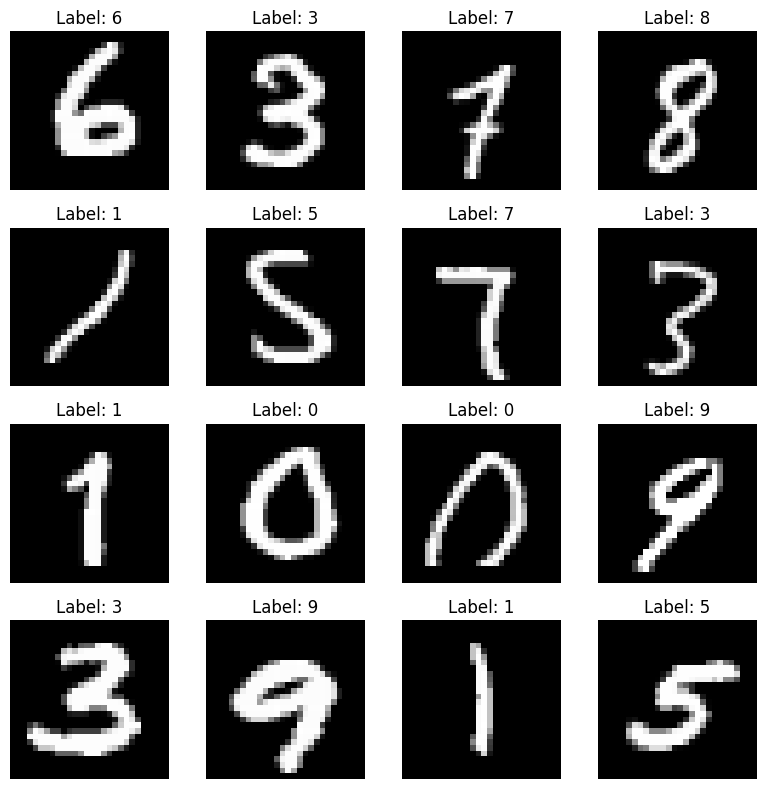

In [8]:
plt.figure(figsize=(8, 8))
for i in range(16):  # 显示前16张
    plt.subplot(4, 4, i+1)
    # 关键：去除批次和通道维度 (64,1,28,28) -> (28,28)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f'Label: {labels[i].item()}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [9]:
labels[0:16]

tensor([6, 3, 7, 8, 1, 5, 7, 3, 1, 0, 0, 9, 3, 9, 1, 5])

In [10]:
images[0].shape

torch.Size([1, 28, 28])

In [11]:
def load_data_mnist(batch_size, resize=None):
    """下载MNIST数据集，然后将其加载到内存中"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.MNIST(
        root="./data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.MNIST(
        root="./data", train=False, transform=trans, download=True)
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=get_dataloader_workers()))

In [12]:
def get_enhanced_data_loaders(batch_size=128):
    """使用数据增强的数据加载器"""
    
    # 训练集：添加数据增强
    train_transform = transforms.Compose([
        transforms.RandomRotation(10),           # 随机旋转±10度
        transforms.RandomAffine(5, translate=(0.1, 0.1)),  # 随机平移
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))  # 标准化
    ])
    
    # 测试集：只做标准化
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    train_dataset = torchvision.datasets.MNIST(
        root='./data', train=True, transform=train_transform, download=True
    )
    test_dataset = torchvision.datasets.MNIST(
        root='./data', train=False, transform=test_transform, download=True
    )
    
    train_loader = data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=get_dataloader_workers()
    )
    test_loader = data.DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=get_dataloader_workers()
    )
    
    return train_loader, test_loader

In [13]:
class MLP(nn.Module):
    def __init__(self, dropout=0.1):
        # 调用MLP的父类Module的构造函数来执行必要的初始化。
        super().__init__()
        self.fc1     = nn.Linear(784, 512)
        self.bn1     = nn.BatchNorm1d(512)
        self.fc2     = nn.Linear(512, 256)
        self.bn2     = nn.BatchNorm1d(256)
        self.fc3     = nn.Linear(256, 128)
        self.bn3     = nn.BatchNorm1d(128)
        self.fc4     = nn.Linear(128, 10)
        
        self.relu    = nn.LeakyReLU(0.1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # 展平 [batch, 784]
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout(x)
        
        x = self.fc4(x)
        return x

In [14]:
def evaluate_model(model, test_iter, loss):
    """评估模型在测试集上的性能"""
    model.eval()  # 切换到评估模式（关闭dropout和batch norm）
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():  # 不计算梯度，节省内存和计算
        for X, y in test_iter:
            outputs = model(X)
            
            # 计算损失
            l = loss(outputs, y)
            if l.dim() > 0:  # 如果是向量，求均值
                l = l.mean()
            total_loss += l.item()
            
            # 计算准确率
            _, predicted = torch.max(outputs, 1)  # 获取预测类别
            total += y.size(0)
            correct += (predicted == y).sum().item()
    
    avg_loss = total_loss / len(test_iter)
    accuracy = correct / total
    
    return avg_loss, accuracy

def train_and_evaluate(model, train_iter, test_iter, loss, updater, scheduler, epochs=10):
    """训练并评估模型，每个epoch后输出训练损失和测试准确率"""
    model.train()
    
    train_losses = []
    test_losses = []
    test_accuracies = []
    
    for epoch in range(epochs):
        # 训练阶段
        train_loss = 0
        for X, y in train_iter:
            updater.zero_grad()
            outputs = model(X)
            l = loss(outputs, y)
            
            if l.dim() > 0:  # 处理向量形式的loss
                l = l.mean()
            
            l.backward()
            updater.step()
            train_loss += l.item()
        
        # 学习率调度
        scheduler.step()
        
        avg_train_loss = train_loss / len(train_iter)
        train_losses.append(avg_train_loss)
        
        # 评估阶段
        test_loss, test_acc = evaluate_model(model, test_iter, loss)
        test_losses.append(test_loss)
        test_accuracies.append(test_acc)
        
        print(f'Epoch {epoch+1}/{epochs}:')
        print(f'  Train Loss: {avg_train_loss:.4f}')
        print(f'  Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
        print()
    
    return train_losses, test_losses, test_accuracies

In [15]:
import random
def visualize_predictions(model, test_iter, n=10, device='cpu'):
    model.eval()
    X, y = next(iter(test_iter))
    X = X[:n].to(device)
    y = y[:n]
    
    with torch.no_grad():
        outputs = model(X)
        probabilities = torch.softmax(outputs, dim=1)
        _, predictions = torch.max(outputs, 1)
    
    # 绘图
    fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(12, 6))
    axes = axes.flatten()
    
    for i in range(n):
        ax = axes[i]
        # 图片形状为 [1, 28, 28] 或 [28, 28]
        img = X[i].cpu().squeeze()  # 去除通道维度
        ax.imshow(img, cmap='gray')
        true_label = y[i].item()
        pred_label = predictions[i].item()
        prob = probabilities[i][pred_label].item()
        ax.set_title(f'True: {true_label}\nPred: {pred_label} ({prob:.2f})')
        ax.axis('off')
    
    # 隐藏多余的子图
    for i in range(n, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
# 调用示例（在训练完成后）
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model.to(device)
# visualize_predictions(model, test_iter, n=10, device=device)

In [16]:
class CNN(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        # 卷积层 + 池化层
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # 输入通道1，输出32，3x3卷积
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)   # 2x2池化，尺寸减半
        
        # 全连接层（经过两次池化后，28x28 -> 7x7）
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        # x 形状: [batch, 1, 28, 28]
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 28 -> 14
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 14 -> 7
        x = x.view(x.size(0), -1)   # 展平: [batch, 64*7*7]
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [17]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # 当维度不匹配时，用 1x1 卷积对齐 shortcut
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1,
                          stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)   # 残差相加
        out = F.relu(out)
        return out

In [18]:
class ResNet(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        # 初始卷积：28x28 -> 28x28（不降采样）
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(16)

        # 残差层（参考 CNN 的两次 pool，这里用 stride=2 替代 MaxPool）
        self.layer1 = ResidualBlock(16, 32, stride=2)   # 28 -> 14
        self.layer2 = ResidualBlock(32, 64, stride=2)   # 14 -> 7

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(64 * 7 * 7, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))   # [batch, 16, 28, 28]
        x = self.layer1(x)                     # [batch, 32, 14, 14]
        x = self.layer2(x)                     # [batch, 64,  7,  7]
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

MLP
CNN
ResNet

  Training: MLP
Epoch 1/5:
  Train Loss: 0.4982
  Test Loss: 0.1372, Test Accuracy: 0.9570 (95.70%)

Epoch 2/5:
  Train Loss: 0.2057
  Test Loss: 0.1001, Test Accuracy: 0.9672 (96.72%)

Epoch 3/5:
  Train Loss: 0.1446
  Test Loss: 0.0697, Test Accuracy: 0.9770 (97.70%)

Epoch 4/5:
  Train Loss: 0.1099
  Test Loss: 0.0549, Test Accuracy: 0.9825 (98.25%)

Epoch 5/5:
  Train Loss: 0.0885
  Test Loss: 0.0500, Test Accuracy: 0.9838 (98.38%)



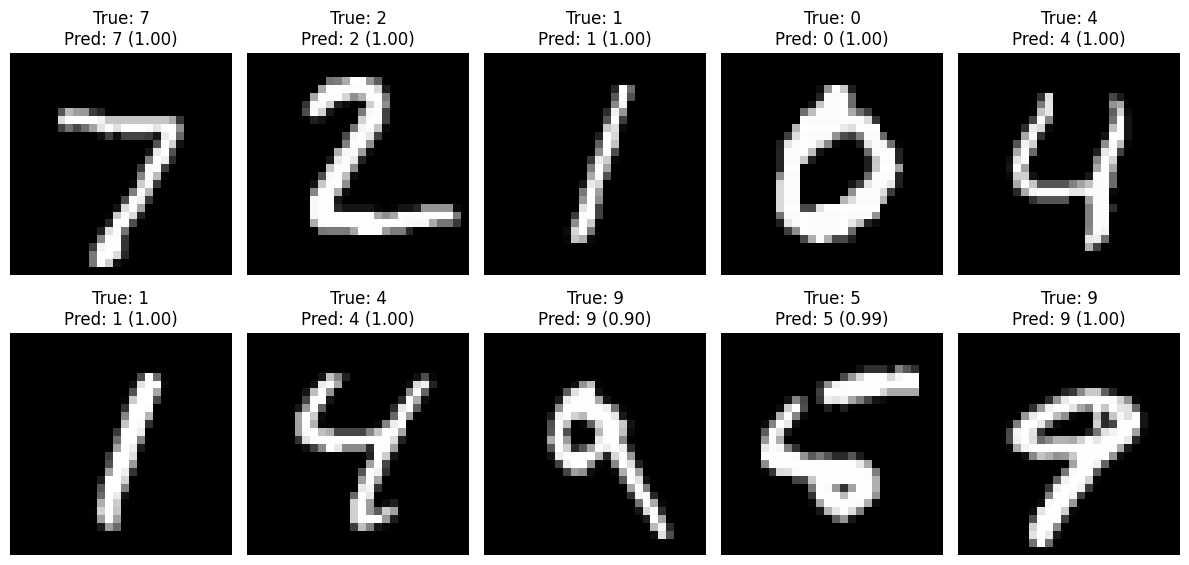


  Training: CNN
Epoch 1/1:
  Train Loss: 0.2922
  Test Loss: 0.0548, Test Accuracy: 0.9819 (98.19%)



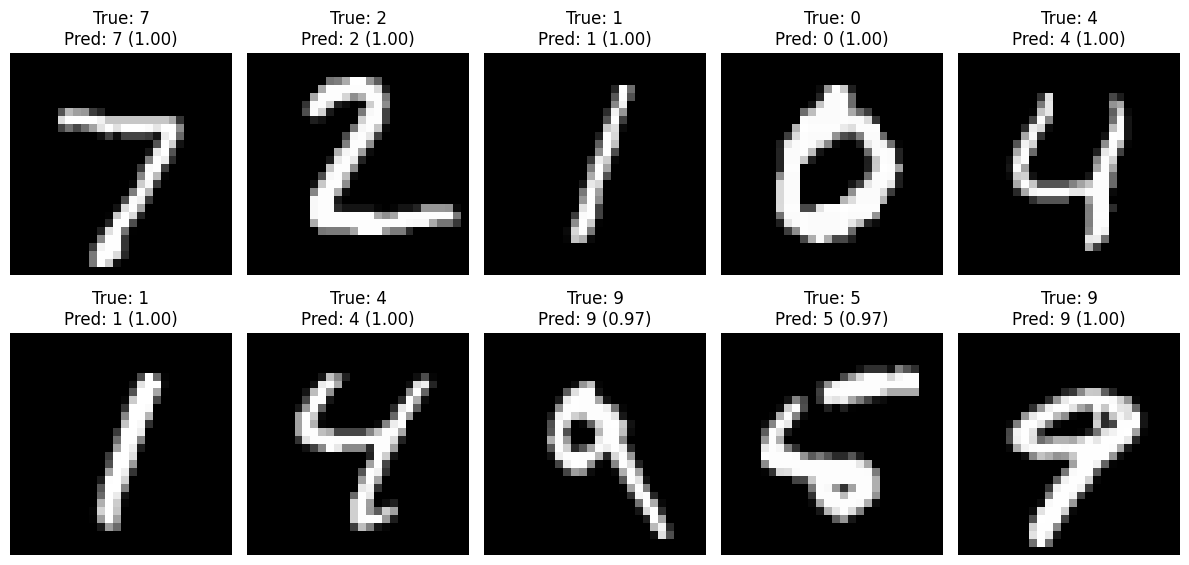


  Training: ResNet
Epoch 1/1:
  Train Loss: 0.1638
  Test Loss: 0.0730, Test Accuracy: 0.9753 (97.53%)



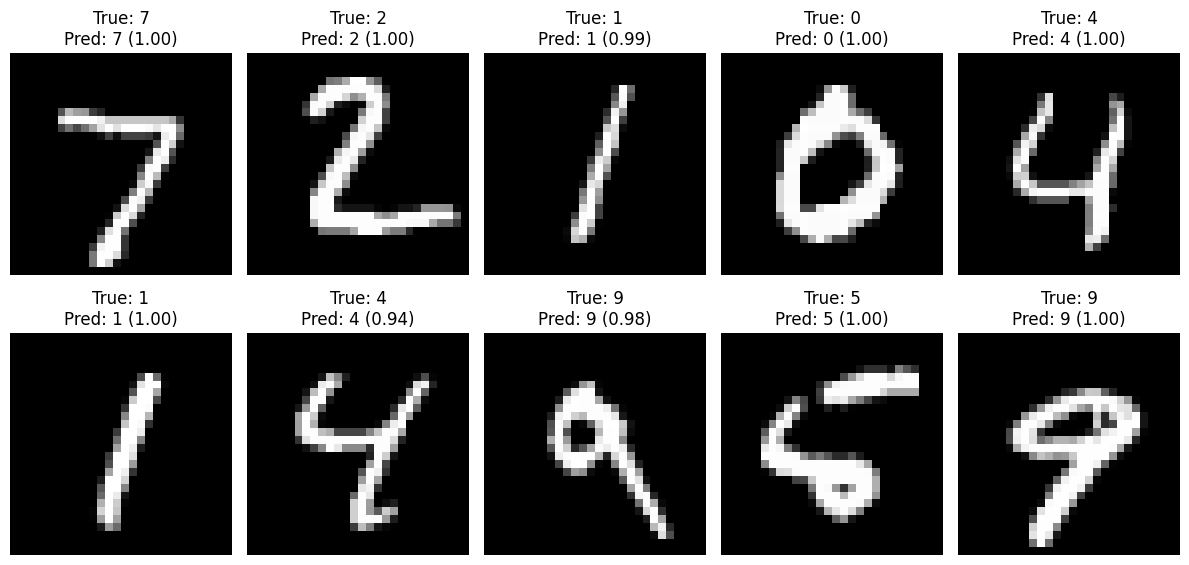

In [19]:
# ── 统一训练入口 ──────────────────────────────────────────
CONFIGS = [
    {
        "name":       "MLP",
        "model":      MLP(dropout=0.1),
        "data_fn":    get_enhanced_data_loaders,   # 带数据增强
        "optimizer":  "Adam",
        "batch_size": 256,
        "lr":         0.001,
        "epochs":     5,
    },
    {
        "name":       "CNN",
        "model":      CNN(dropout=0.5),
        "data_fn":    load_data_mnist,             # 原始数据
        "optimizer":  "AdamW",
        "batch_size": 256,
        "lr":         0.001,
        "epochs":     1,
    },
    {
        "name":       "ResNet",
        "model":      ResNet(dropout=0.3),
        "data_fn":    load_data_mnist,             # 原始数据
        "optimizer":  "AdamW",
        "batch_size": 256,
        "lr":         0.001,
        "epochs":     1,
    },
]

loss = nn.CrossEntropyLoss()
trained_models = {}

Selected_CONFIGS = CONFIGS[0:3]
for cfg in Selected_CONFIGS:
    print(cfg["name"])
for cfg in Selected_CONFIGS:
    print(f"\n{'='*40}\n  Training: {cfg['name']}\n{'='*40}")
    
    model = cfg["model"]
    train_iter, test_iter = cfg["data_fn"](cfg["batch_size"])
    
    opt_cls = torch.optim.Adam if cfg["optimizer"] == "Adam" else torch.optim.AdamW
    optimizer = opt_cls(model.parameters(), lr=cfg["lr"], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"], eta_min=1e-5, last_epoch=-1)
    
    train_and_evaluate(model, train_iter, test_iter, loss, optimizer, scheduler, cfg["epochs"])
    visualize_predictions(model, test_iter, n=10)
    
    trained_models[cfg["name"]] = {
        "model":     model,
        "test_iter": test_iter   # ← 配套保存
    }
    # 保存供后续 FGSM 使用

In [20]:
torch.cuda.is_available()

False

In [21]:
import numpy as np

# 图形化展示预测概率向量
# 修复 show_prediction，让它支持 MNIST 单通道灰度图
def show_prediction(img, label, pred, K=5, adv_img=None, noise=None, norm=True):
    if isinstance(img, torch.Tensor):
        img_np = img.cpu().numpy()
        
        # MNIST: shape [1, 28, 28]，单通道
        if img_np.shape[0] == 1:
            img_np = img_np[0]  # -> [28, 28]
            if norm:
                img_np = img_np * 0.3081 + 0.1307  # 反归一化（如有标准化）
            img_np = np.clip(img_np, 0, 1)
            cmap = 'gray'
        
        label = label.item()
    
    n_plots = 5 if (adv_img is not None and noise is not None) else 2
    fig, ax = plt.subplots(1, n_plots, figsize=(12, 2))
    
    ax[0].imshow(img_np, cmap=cmap)
    ax[0].set_title(f'True: {label}')
    ax[0].axis('off')

    if adv_img is not None and noise is not None:
        # 对抗图像
        adv_np = adv_img.cpu().numpy()
        if adv_np.shape[0] == 1:
            if norm == True:     # 需要反归一化
                adv_np = np.clip(adv_np[0] * 0.3081 + 0.1307, 0, 1)
            else:
                adv_np = np.clip(adv_np[0], 0, 1)
                
        ax[1].imshow(adv_np, cmap=cmap)
        ax[1].set_title('Adversarial')
        ax[1].axis('off')

        # 噪声可视化（归一化到 [0,1] 方便观察）
        noise_np = noise.cpu().numpy()
        if noise_np.shape[0] == 1:
            noise_np = noise_np[0]
        noise_np = noise_np * 0.5 + 0.5
        ax[2].imshow(noise_np, cmap='RdBu')
        ax[2].set_title(f'Noise (ε={epsilon})')
        ax[2].axis('off')
        ax[3].axis('off')

    # 预测概率柱状图
    if abs(pred.sum().item() - 1.0) > 1e-4:
        pred = torch.softmax(pred, dim=-1)
    topk_vals, topk_idx = pred.topk(K, dim=-1)
    topk_vals = topk_vals.cpu().numpy()
    topk_idx  = topk_idx.cpu().numpy()
    ax[-1].barh(np.arange(K), topk_vals * 100,
                color=["C2" if topk_idx[i] == label else "C0" for i in range(K)])
    ax[-1].set_yticks(np.arange(K))
    ax[-1].set_yticklabels(topk_idx)
    ax[-1].invert_yaxis()
    ax[-1].set_xlabel('Confidence (%)')
    ax[-1].set_title('Predictions')
    plt.tight_layout()
    plt.show()
    

In [22]:
def fast_gradient_sign_method(model, imgs, labels, epsilon=0.02):
    model.eval() # 模型处于评估模式
    inp_imgs = imgs.clone().to(device).requires_grad_() # 复制一份imgs，标记为需要求梯度的张量
    preds = model(inp_imgs) # 前向传播获取真实图像的预测结果
    loss = F.cross_entropy(preds, labels)
    loss.backward() # 反向传播

    noise_grad = torch.sign(inp_imgs.grad.detach()).to(imgs.device) # 对抗扰动方向
    fake_imgs = imgs + epsilon * noise_grad # 计算对抗样本
    fake_imgs.detach_() # 分离计算图，避免后续计算梯度
    return fake_imgs, epsilon * noise_grad

In [23]:
def projected_gradient_descent(model, imgs, labels, steps=10, alpha=0.02, epsilon=0.2):
    model.eval()
    
    # 初始化对抗扰动
    delta = torch.zeros_like(imgs, device=device).requires_grad_() # cuda
    fake_imgs = imgs.to(device)

    for t in range(steps):
        # 计算当前的对抗样本
        fake_imgs = imgs.to(device) + delta
        fake_imgs.retain_grad()
        
        preds = model(fake_imgs)
        preds = F.log_softmax(preds, dim=1)

        # 计算损失函数并反向传播
        loss = F.nll_loss(preds, labels.to(device))
        loss.backward()

        # # 提取梯度方向
        noise_grad = fake_imgs.grad.data.sign().to(device)
        # noise_grad = torch.sign(fake_imgs.grad.detach()).to(device)
        fake_imgs.grad.zero_() # 清空梯度，防止梯度叠加

        # 更新扰动
        delta.data.add_(alpha * noise_grad)
        delta.data.clamp_( - epsilon,  + epsilon) # 将对抗扰动控制在[-eps, eps]范围

    return fake_imgs.to(imgs.device).detach_(), delta.detach_().to(imgs.device)

In [24]:
def cw_loss(Z, delta, target_labels, c=0.5, loss_func=None):
    # 该函数用于计算目标函数(loss)
    # Z 为模型的 logits 层结果
    # delta 为像素空间中的扰动（用于约束 L2）
    one_hot = F.one_hot(target_labels, num_classes=Z.shape[-1]).to(device)
    
    # 注意：不能用 Z*(1-one_hot) 直接 max，否则全负 logits 时会被 0 干扰
    Z_not_t = Z.masked_fill(one_hot.bool(), float('-inf')).max(dim=-1)[0]
    Z_t = torch.sum(Z * one_hot, dim=-1)
    
    loss = loss_func(delta, torch.zeros_like(delta)) + c * torch.clamp(Z_not_t - Z_t, min=0).sum()
    return loss

def cw_attack(model, imgs, target_labels, c=1, num_epoch=50, lr=1e-2, input_normalized=False, mean=(0.1307,), std=(0.3081,)):
    # 该函数用于进行 CW 攻击，返回值为：
    # 对抗样本，噪声（均与输入 imgs 处于同一空间）
    
    model.eval()
    x_in = imgs.clone().to(device)
    target_labels = target_labels.to(device)

    # 将输入统一映射到像素空间 [0,1]，CW 在该空间中优化
    if input_normalized:
        mean_t = torch.tensor(mean, device=device, dtype=x_in.dtype).view(1, -1, 1, 1)
        std_t = torch.tensor(std, device=device, dtype=x_in.dtype).view(1, -1, 1, 1)
        x_01 = torch.clamp(x_in * std_t + mean_t, 0.0, 1.0)
    else:
        mean_t, std_t = None, None
        x_01 = torch.clamp(x_in, 0.0, 1.0)

    eps = 1e-6
    x_for_atanh = torch.clamp(x_01 * 2 - 1, min=-1 + eps, max=1 - eps)
    w = torch.atanh(x_for_atanh).detach().requires_grad_()
    optimizer = torch.optim.Adam([w], lr=lr)
    mseloss = torch.nn.MSELoss()

    for _ in range(num_epoch):
        optimizer.zero_grad()

        adv_01 = 0.5 * (torch.tanh(w) + 1)
        delta_01 = adv_01 - x_01

        # 再把像素空间对抗样本映射回模型输入空间
        if input_normalized:
            adv_for_model = (adv_01 - mean_t) / std_t
        else:
            adv_for_model = adv_01

        Z = model(adv_for_model)
        loss = cw_loss(Z, delta_01, target_labels, c=c, loss_func=mseloss)
        loss.backward()
        optimizer.step()

    adv_01 = 0.5 * (torch.tanh(w) + 1)
    if input_normalized:
        adv_out = (adv_01 - mean_t) / std_t
    else:
        adv_out = adv_01

    noise_out = adv_out - x_in
    return adv_out.to(imgs.device).detach_(), noise_out.to(imgs.device).detach_()

接下来我们评估对抗样本在预训练模型上的表现:

In [46]:
name = "MLP"
func = "pgd"
model = trained_models[name]["model"]

# 可视化是否需要反归一化（只对 MLP）
norm = (name == "MLP")
# CW 是否需要先反归一化到 [0,1]（只对 MLP）
input_normalized_for_attack = (name == "MLP")

# 选用测试集, 按要求设置 batch_size = 100
batch_size = 100
if name == "MLP":
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    test_dataset = torchvision.datasets.MNIST(
        root='./data', train=False, transform=test_transform, download=True
    )
    test_iter = data.DataLoader(
        test_dataset, batch_size=batch_size, shuffle=True, num_workers=get_dataloader_workers()
    )
else:
    # 只有 ToTensor
    trans = transforms.ToTensor()
    test_dataset = torchvision.datasets.MNIST(
        root='./data', train=False, transform=trans, download=True
    )
    test_iter = data.DataLoader(
        test_dataset, batch_size=batch_size, shuffle=True, num_workers=get_dataloader_workers()
    )

img_batch, label_batch = next(iter(test_iter))

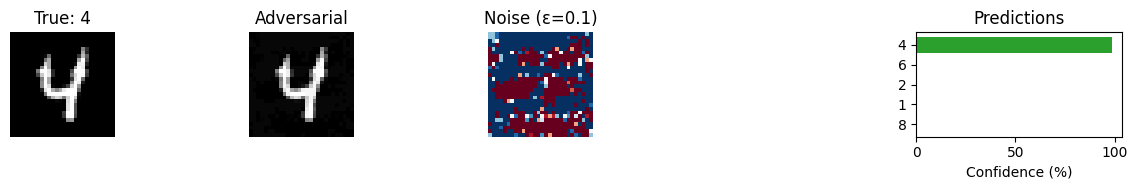

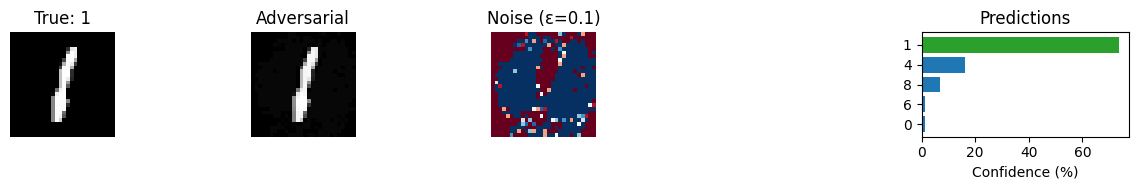

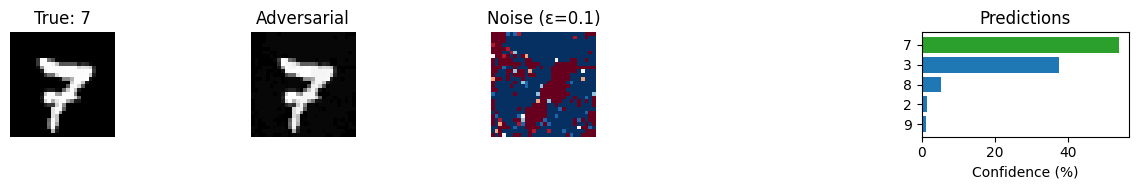

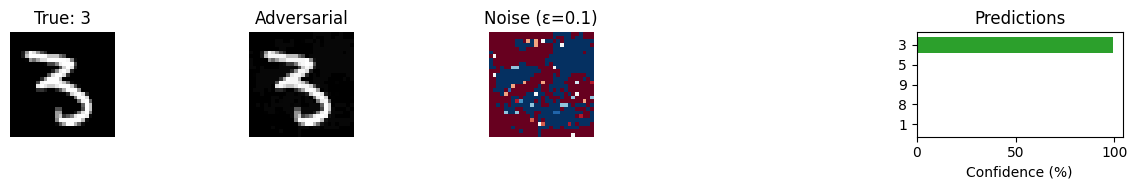

In [47]:
epsilon = 0.1

if func == "fgsm":
    adv_imgs, noise = fast_gradient_sign_method(model, img_batch, label_batch, epsilon=epsilon)
elif func == "pgd":
    adv_imgs, noise = projected_gradient_descent(
        model, img_batch, label_batch, steps=10, alpha=0.02, epsilon=epsilon
    )
elif func == "cw":
    # 目标攻击：确保目标标签不等于真实标签
    target_labels = (label_batch + 3) % 10
    adv_imgs, noise = cw_attack(
        model,
        img_batch,
        target_labels,
        c=1,
        num_epoch=50,
        lr=1e-2,
        input_normalized=input_normalized_for_attack
    )

with torch.no_grad():
    adv_preds = model(adv_imgs.to(device))

for i in range(1, 17, 5):
    show_prediction(
        img_batch[i],
        label_batch[i],
        adv_preds[i],
        adv_img=adv_imgs[i],
        noise=noise[i],
        norm=norm
    )

In [48]:
correct_clean, correct_adv = 0, 0
total_l2_dist = 0
total = 0

with torch.no_grad():
    clean_preds = model(img_batch.to(device))
    correct_clean = (clean_preds.argmax(1) == label_batch.to(device)).sum().item()

with torch.no_grad():
    adv_preds = model(adv_imgs.to(device))
    correct_adv = (adv_preds.argmax(1) == label_batch.to(device)).sum().item()

# L2 距离：每张图像单独算，再累加
noise_flat = noise.view(noise.size(0), -1)          # [batch, 784]
l2_dist    = torch.norm(noise_flat, p=2, dim=1)     # [batch]
total_l2_dist += l2_dist.sum().item()    
    
total = len(label_batch)
print(f"Clean accuracy:      {correct_clean/total:.2%}")
print(f"Adversarial accuracy:{correct_adv/total:.2%}")
print(f"Attack success rate: {(correct_clean - correct_adv)/total:.2%}")
print(f"Avg L2 distance:     {total_l2_dist/total:.4f}")

Clean accuracy:      98.00%
Adversarial accuracy:65.00%
Attack success rate: 33.00%
Avg L2 distance:     2.7158
